In [ ]:
!pip install -qU av==17.0.1 transformers==5.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 66.9 MB/s eta 0:00:00


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from huggingface_hub import login
from PIL import Image
from transformers import Sam3Model, Sam3Processor
from transformers.video_utils import load_video

In [ ]:
login()

In [ ]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


In [ ]:
model = Sam3Model.from_pretrained("facebook/sam3", device_map="auto")
processor = Sam3Processor.from_pretrained("facebook/sam3")

# Load image
image_url = "https://github.com/facebookresearch/sam3/blob/main/assets/images/groceries.jpg?raw=true"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# Segment using text prompt
inputs = processor(images=image, text="blown paper bags", return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist()
)[0]

print(f"Found {len(results['masks'])} objects")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Found 4 objects


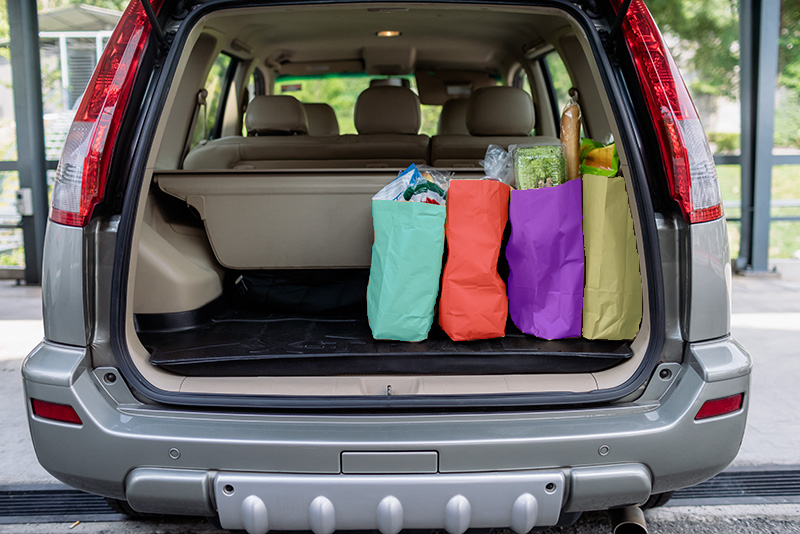

In [ ]:
overlay_masks(image, results["masks"])

In [ ]:
file_id = "1g2a2-HLEuwWFMsoDD1iqTx2NBuiCDSDD"
!gdown $file_id --output movie_players.mp4

Downloading...
From: https://drive.google.com/uc?id=1g2a2-HLEuwWFMsoDD1iqTx2NBuiCDSDD
To: /content/movie_players.mp4
100% 2.43M/2.43M [00:00<00:00, 17.4MB/s]


In [ ]:
video_frames, _ = load_video("movie_players.mp4")

In [ ]:
import gc
import torch
from transformers import Sam3VideoConfig, Sam3VideoModel, Sam3VideoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    major, _ = torch.cuda.get_device_capability(0)
    dtype = torch.bfloat16 if major >= 8 else torch.float16
else:
    dtype = torch.float32

# 解像度を下げる。まずは 560 で試す
image_size = 560

config = Sam3VideoConfig.from_pretrained("facebook/sam3")
config.image_size = image_size

# 検出数を抑える
config.score_threshold_detection = 0.7
config.new_det_thresh = 0.8
config.max_num_objects = 3

model = Sam3VideoModel.from_pretrained(
    "facebook/sam3",
    config=config,
    device_map="auto",
    dtype=dtype,
).eval()

processor = Sam3VideoProcessor.from_pretrained(
    "facebook/sam3",
    size={"height": image_size, "width": image_size},
)

# フレーム数を減らす。まずは短く試す
video_frames_small = video_frames[::2][:30]

inference_session = processor.init_video_session(
    video=video_frames_small,
    inference_device=device,
    inference_state_device="cpu",
    processing_device="cpu",
    video_storage_device="cpu",
    max_vision_features_cache_size=1,
    dtype=dtype,
)

text = "ball"
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text=text,
)

def to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().cpu()
    if isinstance(x, dict):
        return {k: to_cpu(v) for k, v in x.items()}
    if isinstance(x, list):
        return [to_cpu(v) for v in x]
    if isinstance(x, tuple):
        return tuple(to_cpu(v) for v in x)
    return x

outputs_per_frame = {}

with torch.inference_mode():
    for model_outputs in model.propagate_in_video_iterator(
        inference_session=inference_session,
        max_frame_num_to_track=30,
        show_progress_bar=True,
    ):
        processed_outputs = processor.postprocess_outputs(
            inference_session,
            model_outputs,
        )

        outputs_per_frame[model_outputs.frame_idx] = to_cpu(processed_outputs)

        del model_outputs, processed_outputs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"Processed {len(outputs_per_frame)} frames")

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

propagate in video:   0%|          | 0/30 [00:00<?, ?it/s]

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Processed 30 frames


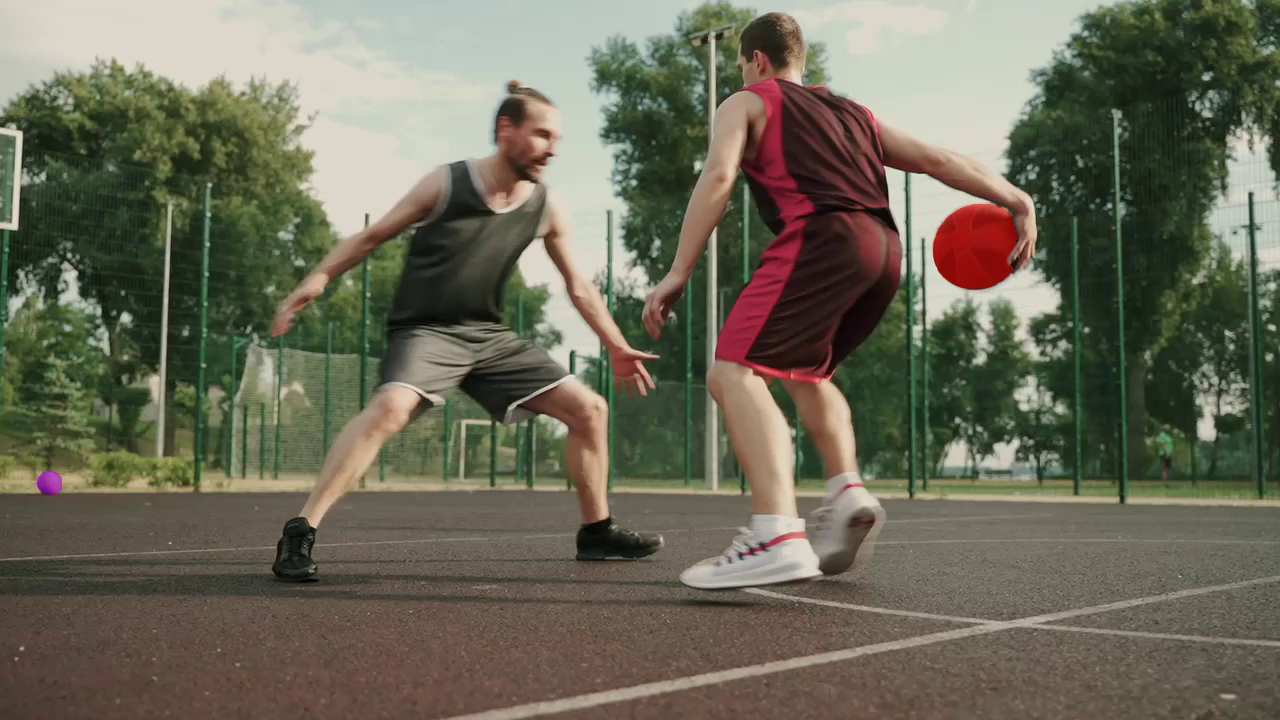

In [ ]:
frame_idx = 0
frame_outputs = outputs_per_frame[frame_idx]
masks = frame_outputs["masks"]
frame = video_frames[frame_idx]
overlay_masks(Image.fromarray(frame), masks)